In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# Dynamically determine the number of classes from the loaded dataset

base_model = applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 35)             │         8,995 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,251 (92.02 MB)

 Trainable params: 533,539 (2.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [28]:
import os
import requests
import zipfile
import shutil
import tensorflow as tf

dataset_url = 'https://github.com/spMohanty/PlantVillage-Dataset/archive/refs/heads/master.zip'
data_dir = '/content/plant_village_data'

# Download and extract if missing
if not os.path.exists(data_dir):
    print('Downloading dataset (this may take a minute)...')
    r = requests.get(dataset_url)
    with open('dataset.zip', 'wb') as f:
        f.write(r.content)
    print('Extracting images...')
    with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print('Extraction complete.')

#  path
base_path = os.path.join(data_dir, 'PlantVillage-Dataset-master', 'raw', 'color')

# Load datasets using Keras
print('Loading datasets...')
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

print('Datasets imported successfully!')

Loading datasets...
Found 46094 files belonging to 35 classes.
Using 36876 files for training.
Found 46094 files belonging to 35 classes.
Using 9218 files for validation.
Datasets imported successfully!


In [29]:
import tensorflow as tf

# batches to move from validation to test
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print(f'Validation batches: {tf.data.experimental.cardinality(val_ds)}')
print(f'Test batches: {tf.data.experimental.cardinality(test_ds)}')

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Validation batches: 145
Test batches: 144


In [30]:
import os
from pathlib import Path
import imghdr

# Helper to remove non-image files
print("Cleaning dataset folders...")
image_extensions = ["png", "jpg", "jpeg", "bmp"]
removed_count = 0

for img_path in Path(base_path).rglob('*'):
    if img_path.is_file():
        extension = imghdr.what(img_path)
        if extension not in image_extensions:
            os.remove(img_path)
            removed_count += 1

print(f"Cleanup finished. Removed {removed_count} invalid files.")

Cleaning dataset folders...
Cleanup finished. Removed 0 invalid files.


In [31]:
from google.colab import drive
import os

# Mount Google Drive to save the model
drive.mount('/content/drive')

# Create a directory in Drive to store the model
save_path = '/content/drive/MyDrive/plant_disease_model/'
os.makedirs(save_path, exist_ok=True)

# Define the checkpoint callback to save the model during training
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(save_path, 'best_plant_model.keras'),
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# Training with the Drive checkpoint callback enabled
print("Starting training with Drive backup...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[checkpoint_callback]
)

print(f"Model training complete and saved to: {save_path}")

Starting training with Drive backup...
Epoch 1/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8238 - loss: 0.6377
Epoch 1: val_accuracy improved from None to 0.95531, saving model to /content/drive/MyDrive/plant_disease_model/best_plant_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/plant_disease_model/best_plant_model.keras
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 135s 108ms/step - accuracy: 0.9009 - loss: 0.3307 - val_accuracy: 0.9553 - val_loss: 0.1356
Epoch 2/5
1152/1153 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9563 - loss: 0.1306
Epoch 2: val_accuracy improved from 0.95531 to 0.96876, saving model to /content/drive/MyDrive/plant_disease_model/best_plant_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/plant_disease_model/best_plant_model.keras
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 131s 103ms/step - accuracy: 0.9573 - loss: 0.1256 - val_accuracy: 0.9688 - val_loss: 0.0918
Epoch 3/5
1152/1153 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy

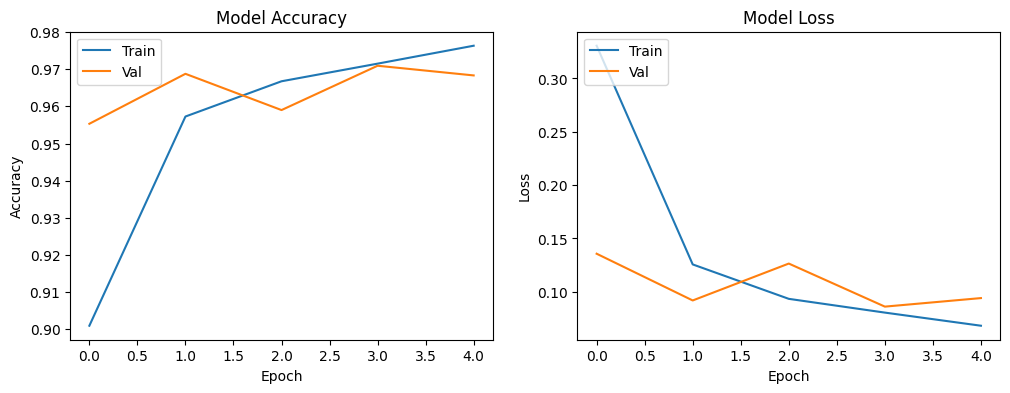

Evaluating on Test Set:
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - accuracy: 0.9681 - loss: 0.1000
Test Accuracy: 96.81%


In [33]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

plt.show()

# Evaluate on the test set
print("Evaluating on Test Set:")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {accuracy*100:.2f}%")